In [1]:
# Import Python libraries to work with SciServer
import SciServer.CasJobs as CasJobs # query with CasJobs
import SciServer.SciDrive as SciDrive   # read/write to/from SciDrive
import SciServer.SkyServer as SkyServer   # show individual objects and generate thumbnail images through SkyServer
print('SciServer libraries imported')

# Import other libraries for use in this notebook.
import numpy as np                  # standard Python lib for math ops
#from scipy.misc import imsave       # save images as files
import pandas                       # data manipulation package
import matplotlib.pyplot as plt     # another graphing package
import os                           # manage local files in your Compute containers
print('Supporting libraries imported')

from astropy.io import ascii

# Apply some special settings to the imported libraries
# ensure columns get written completely in notebook
pandas.set_option('display.max_colwidth', None)
# do *not* show python warnings 
import warnings
warnings.filterwarnings('ignore')
print('Settings applied')

SciServer libraries imported
Supporting libraries imported
Settings applied


In [2]:
# pandas.set_option('display.max_rows', None)
# # pandas.set_option('display.max_rows', 20)

# query = """
# SELECT COLUMN_NAME
# FROM INFORMATION_SCHEMA.COLUMNS
# WHERE TABLE_NAME = 'PhotoObj'
# """

# cols = CasJobs.executeQuery(query, "dr16")
# print(cols)

In [3]:
# Find objects in the Sloan Digital Sky Survey's Data Release 14.
#
# Query the Sloan Digital Sky Serveys' Data Release 14.
# For the database schema and documentation see http://skyserver.sdss.org/dr14
#
# This query finds all galaxies with a size (petror90_r) greater than 10 arcseconds, within
# a region of sky with 100 < RA < 250, a redshift between 0.02 and 0.5, and a g-band magnitude brighter than 17.
# 
# First, store the query in an object called "query"
query="""
SELECT p.objId,p.ra,p.dec,p.petror90_r, p.expAB_r,
    p.dered_u as u, p.dered_g as g, p.dered_r as r, p.dered_i as i, 
    s.z, s.plate, s.mjd, s.fiberid
FROM galaxy AS p
   JOIN SpecObj AS s ON s.bestobjid = p.objid
WHERE s.z between 0.00 and 0.5
    and p.ra between 110 and 260
    and p.g < 17
    and p.dec between -5 and 75
"""
#Then, query the database. The answer is a table that is being returned to a dataframe that we've named all_gals.
all_gals = CasJobs.executeQuery(query, "dr16")

print("SQL query finished.")
print("SQL query returned " + str(len(all_gals))+ " galaxies")
all_gals[0:10]

SQL query finished.
SQL query returned 92018 galaxies


,objId,ra,dec,petror90_r,expAB_r,u,g,r,i,z,plate,mjd,fiberid
0,1237658192144564361,119.499831,26.502435,9.221048,0.762580,16.83762,15.56560,15.00769,14.65489,0.046296,929,52581,292
1,1237658192144761194,119.974287,26.789056,11.334130,0.486925,17.14555,15.80206,15.14164,14.77535,0.047407,929,52581,164
2,1237658192144761218,119.868821,26.889619,12.095800,0.598299,16.22401,14.89076,14.25925,13.93336,0.026470,929,52581,173
3,1237658192144892287,120.203107,26.986249,14.454600,0.709428,18.45153,16.80955,16.08790,15.73838,0.022836,929,52581,157
4,1237658192145023296,120.327109,27.212636,15.230550,0.484202,17.16539,15.27100,14.44235,14.03795,0.047003,929,52581,508
5,1237658192145088727,120.517542,27.224915,18.768810,0.623960,16.36690,15.03339,14.42258,14.11007,0.022090,4458,55536,690
6,1237658192145088775,120.406129,27.359288,11.799310,0.517459,17.53892,15.64897,14.75164,14.30678,0.047070,929,52581,513
7,1237658192145154071,120.488695,27.439262,9.869446,0.857562,18.20600,16.29349,15.38759,14.96156,0.076992,929,52581,501
8,1237658192146202642,122.499935,29.063852,55.059300,0.383507,18.60093,16.63505,15.78872,15.39838,0.039960,930,52618,167
9,1237658192146202713,122.518188,29.031862,12.382560,0.392677,17.88244,16.46336,15.85139,15.49136,0.047814,930,52618,168


In [46]:
import numpy as np
import pandas as pd

THETA_MIN = 0.5    # minimum angular separation (degrees)
THETA_MAX = 5.0    # maximum angular separation (degrees)
N_BINS    = 10     # number of linearly spaced bins
N_RANDOM  = 10000  # number of random catalog points per slice
# Changed code to use number of gals in slice as N_RANDOM, since further redshifts have fewer than closer
SEED      = 42     # random seed for reproducibility

Z_MIN     = 0.0    # lower bound of redshift range
Z_MAX     = 0.3    # upper bound of redshift range (galaxies beyond discarded)
DZ        = 0.01   # redshift slice width

all_gals_trimmed = all_gals[(all_gals["z"] >= Z_MIN) & (all_gals["z"] < Z_MAX)].copy()

# Build slice edges: [0.00, 0.01, 0.02, ..., 0.30]
z_edges = np.round(np.arange(Z_MIN, Z_MAX + DZ, DZ), decimals=10)
n_slices = len(z_edges) - 1
print(f"Defined {n_slices} redshift slices of width dz={DZ}.")

bins        = np.linspace(THETA_MIN, THETA_MAX, N_BINS + 1)
bin_centres = 0.5 * (bins[:-1] + bins[1:])

def angular_separation(ra1, dec1, ra2, dec2):
    ra1, dec1, ra2, dec2 = map(np.radians, [ra1, dec1, ra2, dec2])
    d_ra  = ra2  - ra1
    d_dec = dec2 - dec1
    a = (np.sin(d_dec / 2) ** 2
         + np.cos(dec1) * np.cos(dec2) * np.sin(d_ra / 2) ** 2)
    return np.degrees(2 * np.arcsin(np.sqrt(np.clip(a, 0, 1))))

def count_pairs(ra_a, dec_a, ra_b, dec_b, bins, same_catalog=False):
    counts = np.zeros(len(bins) - 1, dtype=np.int64)
    n = len(ra_a)
    if same_catalog:
        for i in range(n - 1):
            sep = angular_separation(ra_a[i], dec_a[i], ra_b[i+1:], dec_b[i+1:])
            counts += np.histogram(sep, bins=bins)[0]
    else:
        for i in range(n):
            sep = angular_separation(ra_a[i], dec_a[i], ra_b, dec_b)
            counts += np.histogram(sep, bins=bins)[0]
    return counts

def landy_szalay(DD, DR, RR, n_data, n_random):
    norm_DD = n_data   * (n_data   - 1) / 2
    norm_RR = n_random * (n_random - 1) / 2
    norm_DR = n_data   * n_random

    dd = DD / norm_DD
    rr = RR / norm_RR
    dr = DR / norm_DR

    with np.errstate(invalid="ignore", divide="ignore"):
        omega = np.where(rr > 0, (dd - 2 * dr + rr) / rr, np.nan)

    return omega

def make_random_catalog(ra_d, dec_d, n_random, slice_index):
    rng = np.random.default_rng(SEED + slice_index)
    ra_r  = rng.uniform(ra_d.min(),  ra_d.max(),  n_random)
    dec_r = rng.uniform(dec_d.min(), dec_d.max(), n_random)
    return ra_r, dec_r

records = []

for s in range(n_slices):
    z_lo = z_edges[s]
    z_hi = z_edges[s + 1]
    z_mid = round(0.5 * (z_lo + z_hi), 10)

    mask  = (all_gals_trimmed["z"] >= z_lo) & (all_gals_trimmed["z"] < z_hi)
    slice_df = all_gals_trimmed[mask]
    n_data   = len(slice_df)

    print(f"Slice z=[{z_lo:.2f}, {z_hi:.2f}): {n_data} galaxies", end="")

    if n_data < 2:
        print(" — skipped (fewer than 2 galaxies).")
        for theta in bin_centres:
            records.append({
                "z_lo"   : z_lo,
                "z_hi"   : z_hi,
                "z_mid"  : z_mid,
                "theta"  : round(theta, 4),
                "DD"     : 0,
                "DR"     : 0,
                "RR"     : 0,
                "omega"  : np.nan,
            })
        continue

    print(" — computing ...", end="", flush=True)

    ra_d  = slice_df["ra"].values
    dec_d = slice_df["dec"].values

    # ra_r, dec_r = make_random_catalog(ra_d, dec_d, N_RANDOM, slice_index=s) # Original code from Claude
    ra_r, dec_r = make_random_catalog(ra_d, dec_d, len(ra_d), slice_index=s) # My version

    DD = count_pairs(ra_d, dec_d, ra_d, dec_d, bins, same_catalog=True)
    RR = count_pairs(ra_r, dec_r, ra_r, dec_r, bins, same_catalog=True)
    DR = count_pairs(ra_d, dec_d, ra_r, dec_r, bins, same_catalog=False)

    # omega = landy_szalay(DD, DR, RR, n_data, N_RANDOM)
    omega = landy_szalay(DD, DR, RR, n_data, len(ra_d))

    for theta, dd_i, dr_i, rr_i, w in zip(bin_centres, DD, DR, RR, omega):
        records.append({
            "z_lo"   : z_lo,
            "z_hi"   : z_hi,
            "z_mid"  : z_mid,
            "theta"  : round(theta, 4),
            "DD"     : int(dd_i),
            "DR"     : int(dr_i),
            "RR"     : int(rr_i),
            "omega"  : w,
        })

    print(" done.")

results = pd.DataFrame(records, columns=["z_lo", "z_hi", "z_mid", "theta",
                                         "DD", "DR", "RR", "omega"])
results.to_csv('results.csv', index=False)

print(f"\nResults DataFrame: {len(results)} rows "
      f"({n_slices} slices × {N_BINS} bins).")
print("omega > 0 → clustering above random | "
      "omega < 0 → underdensity | "
      "omega = NaN → insufficient data\n")

display(results)

Defined 30 redshift slices of width dz=0.01.
Slice z=[0.00, 0.01): 3713 galaxies — computing ... done.
Slice z=[0.01, 0.02): 3899 galaxies — computing ... done.
Slice z=[0.02, 0.03): 12274 galaxies — computing ... done.
Slice z=[0.03, 0.04): 13918 galaxies — computing ... done.
Slice z=[0.04, 0.05): 12397 galaxies — computing ... done.
Slice z=[0.05, 0.06): 10924 galaxies — computing ... done.
Slice z=[0.06, 0.07): 11248 galaxies — computing ... done.
Slice z=[0.07, 0.08): 9746 galaxies — computing ... done.
Slice z=[0.08, 0.09): 6244 galaxies — computing ... done.
Slice z=[0.09, 0.10): 3157 galaxies — computing ... done.
Slice z=[0.10, 0.11): 1948 galaxies — computing ... done.
Slice z=[0.11, 0.12): 1279 galaxies — computing ... done.
Slice z=[0.12, 0.13): 556 galaxies — computing ... done.
Slice z=[0.13, 0.14): 341 galaxies — computing ... done.
Slice z=[0.14, 0.15): 148 galaxies — computing ... done.
Slice z=[0.15, 0.16): 69 galaxies — computing ... done.
Slice z=[0.16, 0.17): 44 ga

,z_lo,z_hi,z_mid,theta,DD,DR,RR,omega
0,0.00,0.01,0.005,0.725,6023,3188,1662,2.706293
1,0.00,0.01,0.005,1.175,8524,5147,2789,2.211325
2,0.00,0.01,0.005,1.625,10602,7208,3808,1.891791
3,0.00,0.01,0.005,2.075,12214,9052,4651,1.680378
4,0.00,0.01,0.005,2.525,13549,11256,5900,1.389158
...,...,...,...,...,...,...,...,...
295,0.29,0.30,0.295,2.975,0,0,0,NaN
296,0.29,0.30,0.295,3.425,0,0,0,NaN
297,0.29,0.30,0.295,3.875,0,0,0,NaN
298,0.29,0.30,0.295,4.325,0,0,0,NaN


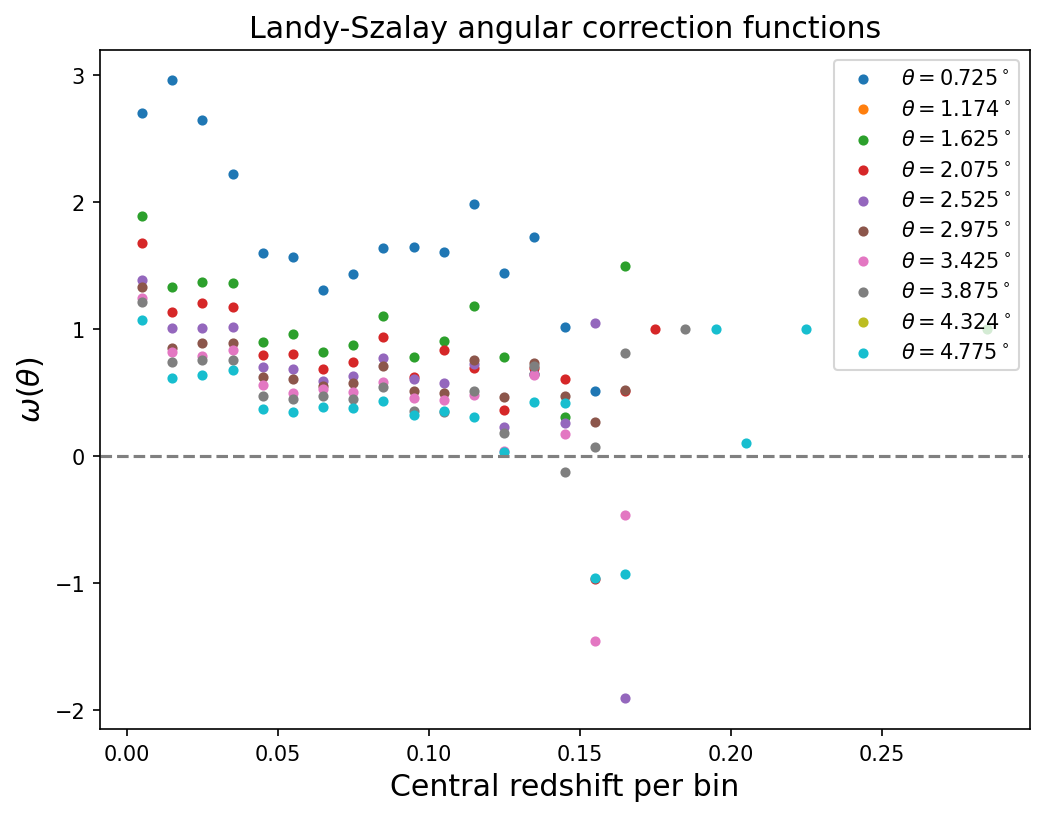

In [48]:
import math

from decimal import Decimal, ROUND_DOWN

results = pd.read_csv('results.csv')

plt.figure(figsize= (8, 6), dpi= 150)
for cen in bin_centres:
    gals = (results[results['theta'] == cen])
    c2 = Decimal(str(cen))
    truncated = c2.quantize(Decimal('0.001'), rounding= ROUND_DOWN)
    plt.scatter(gals['z_mid'], gals['omega'], s=15, label= r'$\theta = $' + str(truncated) + r'$^\circ$')
# plt.scatter(results['z_mid'], results['omega'], s=5)
plt.xlabel('Central redshift per bin', fontsize= 'x-large')
plt.ylabel(r'$\omega(\theta)$', fontsize= 'x-large')
plt.title(r'Landy-Szalay angular correction functions', fontsize= 'x-large')
plt.axhline(0, c= 'gray', linestyle= '--')
# plt.ylim(-2, 3)
plt.legend()
plt.savefig('LS_Plot.png', overwrite= True)
# plt.show()

In [24]:
THETA_MIN = 0.5    # minimum angular separation (degrees)
THETA_MAX = 5.0    # maximum angular separation (degrees)
N_BINS    = 10     # number of linearly spaced bins

bins        = np.linspace(THETA_MIN, THETA_MAX, N_BINS + 1)
bin_centres = 0.5 * (bins[:-1] + bins[1:])
print(bin_centres)

[0.725 1.175 1.625 2.075 2.525 2.975 3.425 3.875 4.325 4.775]


In [51]:
z_edges = np.round(np.arange(Z_MIN, Z_MAX + DZ, DZ), decimals=10)
print(z_edges)
z_vals = []
for i in range(len(z_edges)-1):
    z_vals += [(z_edges[i] + z_edges[i+1])/2]
print(z_vals)

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3 ]
[0.005, 0.015, 0.025, 0.035, 0.045, 0.055, 0.065, 0.07500000000000001, 0.08499999999999999, 0.095, 0.10500000000000001, 0.11499999999999999, 0.125, 0.135, 0.14500000000000002, 0.155, 0.165, 0.175, 0.185, 0.195, 0.20500000000000002, 0.215, 0.225, 0.235, 0.245, 0.255, 0.265, 0.275, 0.28500000000000003, 0.295]


In [ ]:
'''
Landy-Szalay angular correction function:
Commonly previously used, 1 + omega(theta) = DD/RR
where DD is the number of pairs in the sample with an angular separation within theta, and RR is the number of pairs in a randomly generated sample with an angular separation within theta
Landy-Szalay demonstrate that this method and other common previously used ones have greater spread than their proposed method, wherein
1 + omega(theta) = (DD - 2 * DR + RR)/RR
where DD and RR are defined the same, and DR is the number of pairs within the angular separation given a cross-correlation between the galaxies and a random distribution

'''

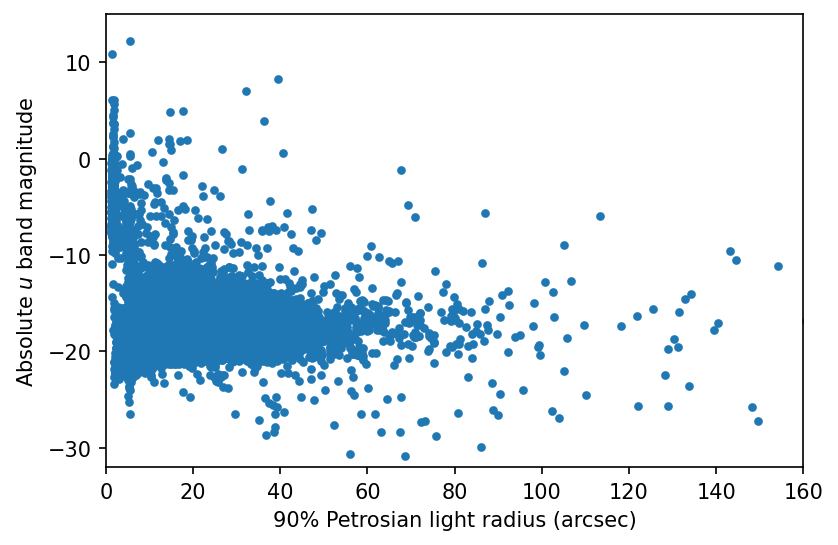

In [78]:
plt.figure(dpi= 150)
plt.scatter(all_gals['petror90_r'], all_gals['u'] - 5 * np.log10((3e5 * all_gals['z'] / 70)*1e6) + 5, s=10)
plt.xlim(0, 160)
plt.ylim(-32, 15)
plt.xlabel('90% Petrosian light radius (arcsec)')
plt.ylabel('Absolute $u$ band magnitude')
plt.show()

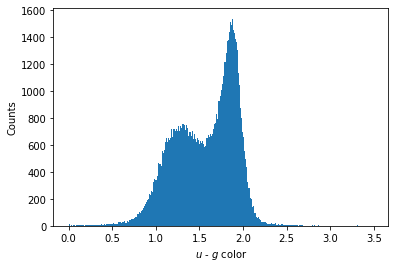

In [60]:
histBins = np.arange(0, 3.5, 0.01)
plt.hist(all_gals['u'] - all_gals['g'], bins= histBins)
plt.xlabel('$u$ - $g$ color')
plt.ylabel('Counts')
plt.show()

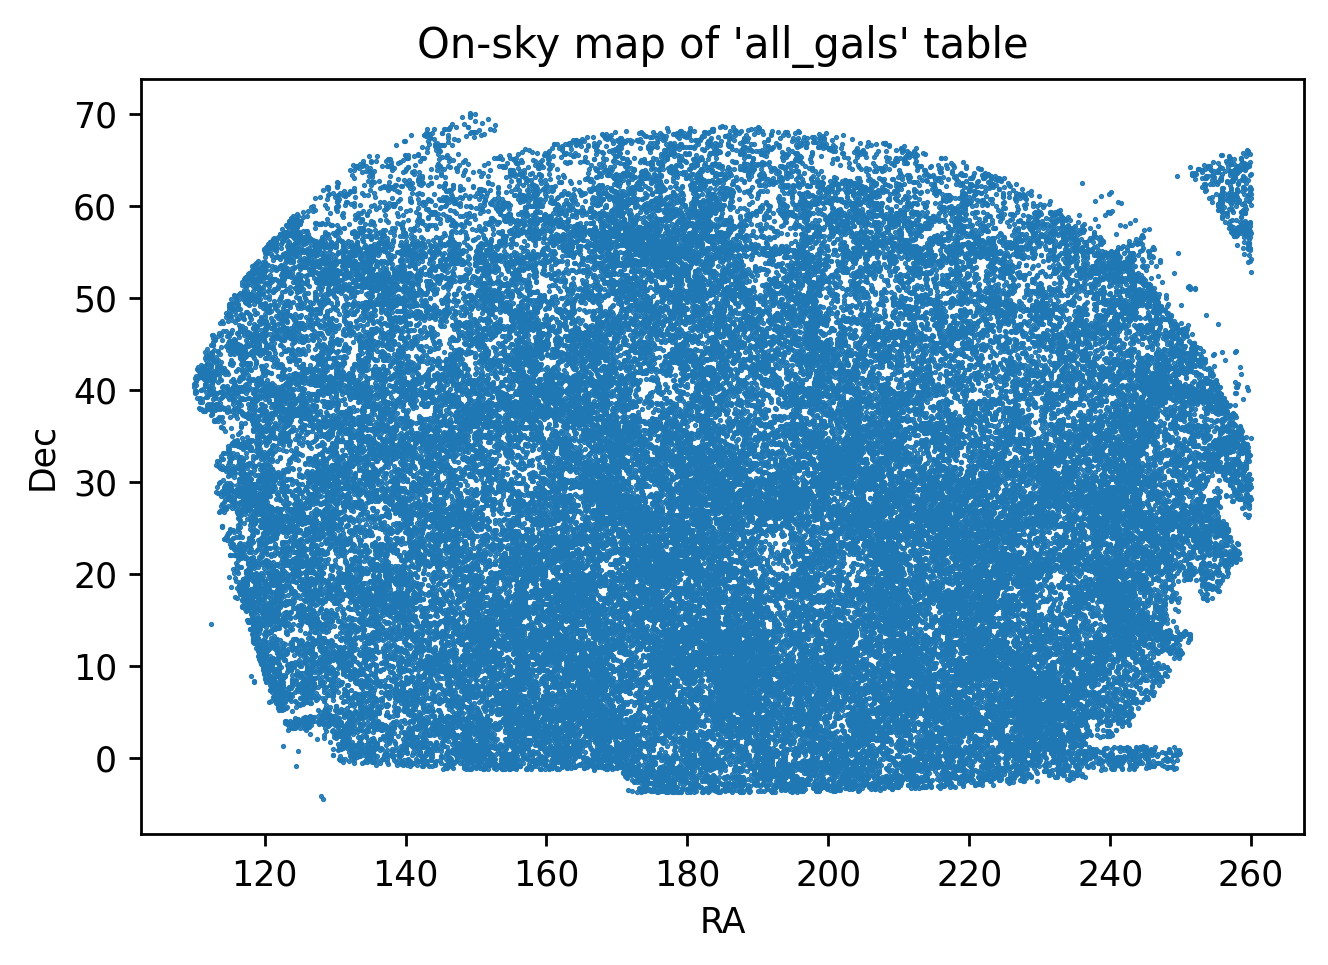

In [4]:
plt.figure(dpi= 250)
plt.scatter(all_gals['ra'], all_gals['dec'], marker= '.', s=1)
plt.title('On-sky map of \'all_gals\' table')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.show()

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49]


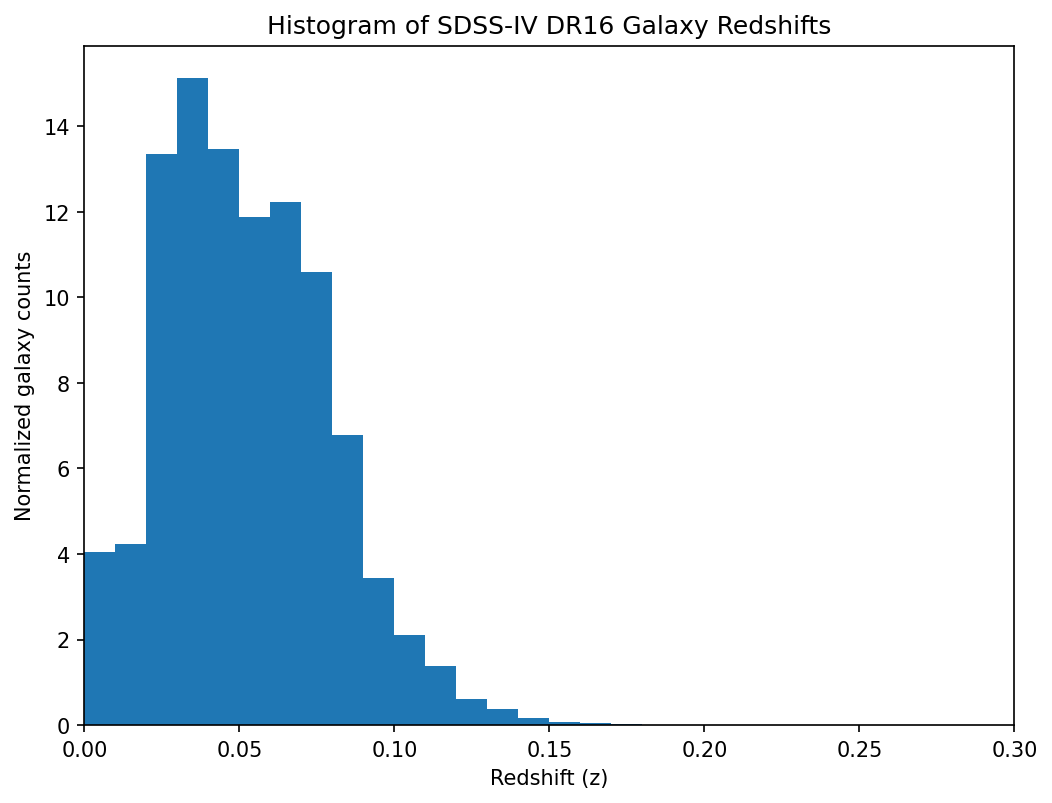

In [10]:
myBins = np.arange(0, 0.5, 0.01)
plt.figure(figsize= (8, 6), dpi= 150)
plt.hist(all_gals['z'], bins= myBins, density= True)
plt.xlim(0, 0.3)
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized galaxy counts')
plt.title('Histogram of SDSS-IV DR16 Galaxy Redshifts')

# plt.show()
plt.savefig('zHist.png')
print(myBins)

In [39]:
zMasks = []
zBins = []
for i in range(len(myBins) - 1):
    zMasks += [(all_gals['z'] > myBins[i]) & (myBins[i+1] > all_gals['z'])] # Construct masks from bins
    zBins += [(myBins[i] + myBins[i+1])/2]

'''
d = cz/H0 = 3e5 km/s * z / 70 km/s/Mpc (answer in Mpc)
'''

counts = []
adjustedMags = []
meanColors = []
reddestGals = []
bluestGals = []

for mask in zMasks:
    counts += [len(all_gals[mask])]
    adjustedMags += [np.mean([all_gals['u'][mask] - 5 * np.log10((3e5 * all_gals['z'][mask] / 70)*1e6) + 5])]
    meanColors += [np.mean(all_gals['u'][mask] - all_gals['g'][mask])]
    reddestGals += [np.min(all_gals['u'][mask] - all_gals['g'][mask])]
    bluestGals += [np.max(all_gals['u'][mask] - all_gals['g'][mask])]

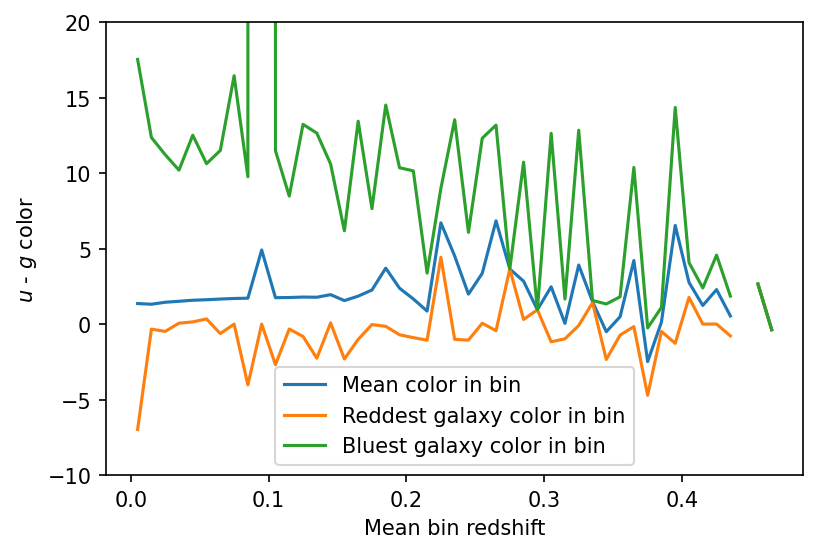

In [49]:
plt.figure(dpi= 150)

plt.plot(zBins, meanColors, label = 'Mean color in bin')
plt.plot(zBins, reddestGals, label = 'Reddest galaxy color in bin')
plt.plot(zBins, bluestGals, label = 'Bluest galaxy color in bin')

# plt.scatter(zBins, meanColors, label = 'Mean color in bin')
# plt.scatter(zBins, reddestGals, label = 'Reddest galaxy color in bin')
# plt.scatter(zBins, bluestGals, label = 'Bluest galaxy color in bin')

# plt.plot(zBins, meanColors)
plt.xlabel('Mean bin redshift')
plt.ylabel('$u$ - $g$ color')
# More positive difference = bluer, more negative = redder
plt.legend()
plt.ylim(-10, 20)
plt.show()

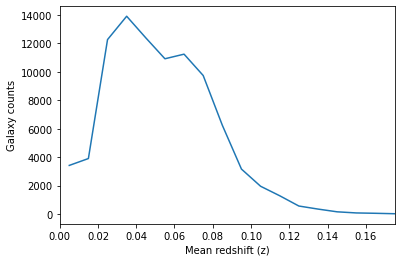

In [33]:
plt.plot(zBins, counts)
plt.xlabel('Mean redshift (z)')
plt.ylabel('Galaxy counts')
plt.xlim(0, 0.175)
plt.show()

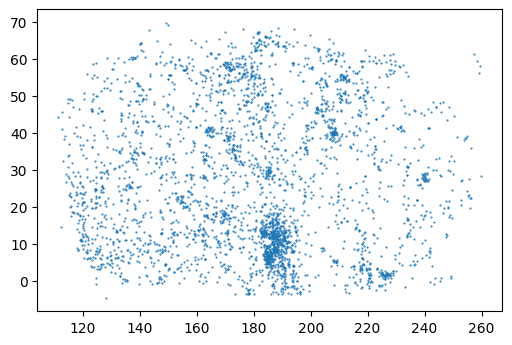

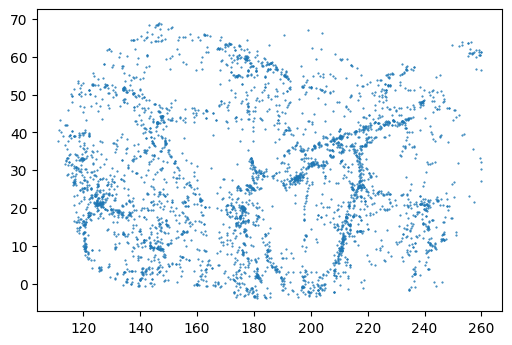

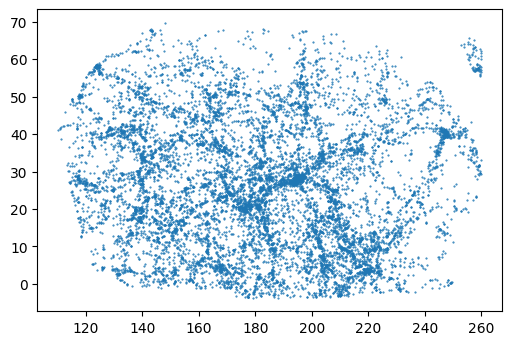

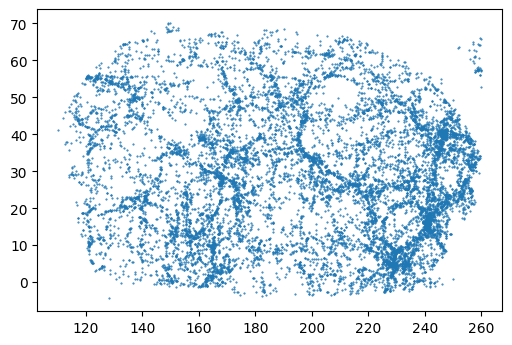

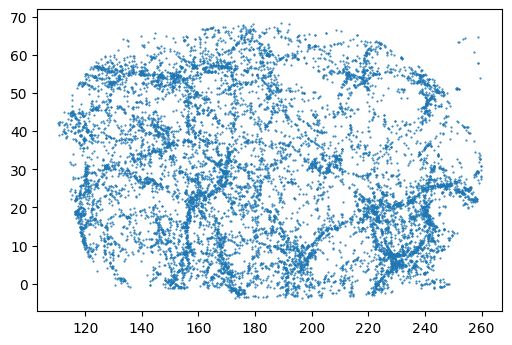

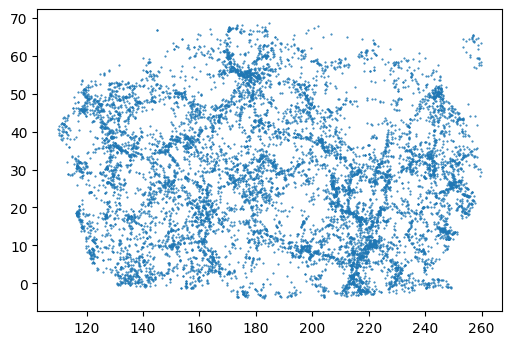

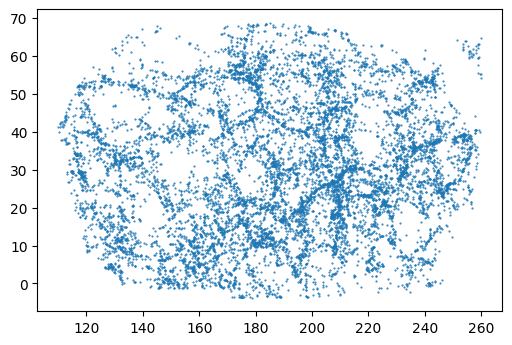

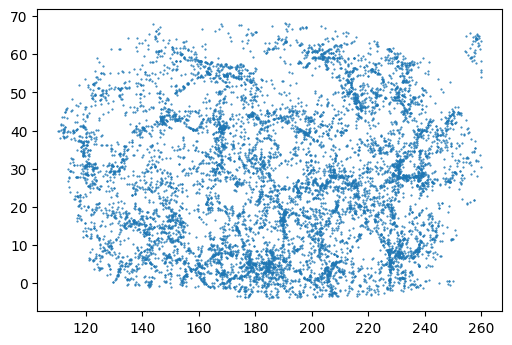

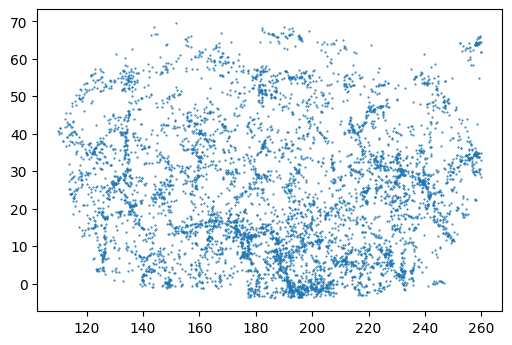

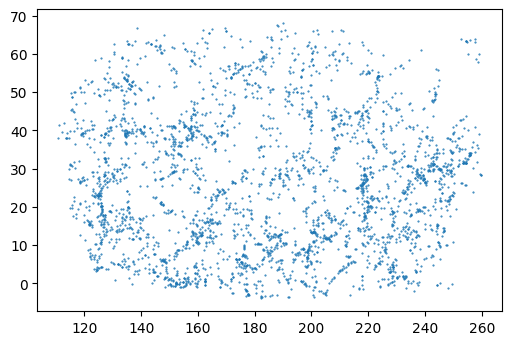

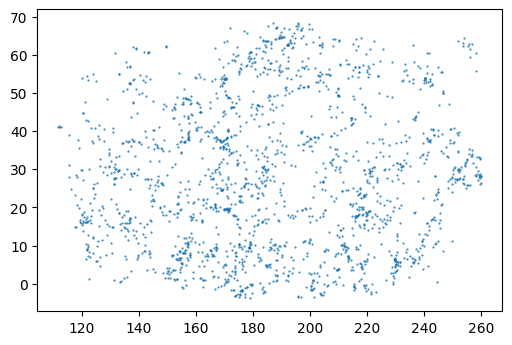

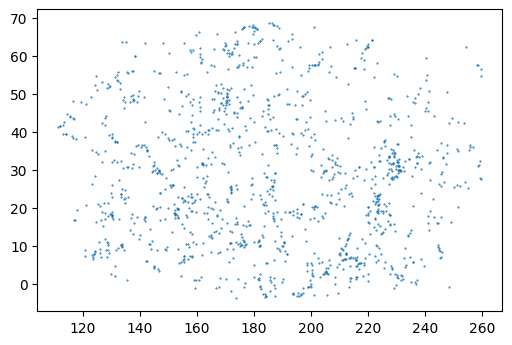

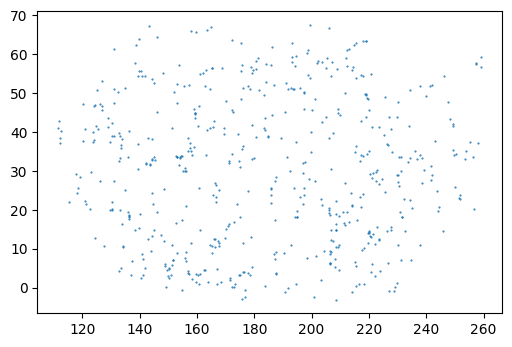

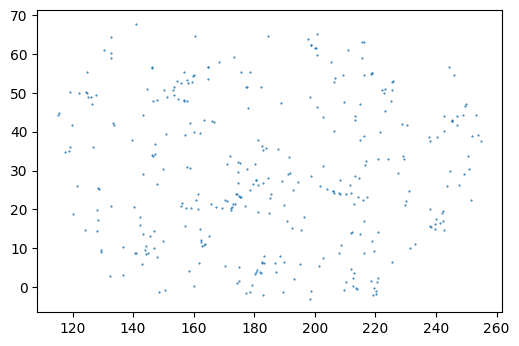

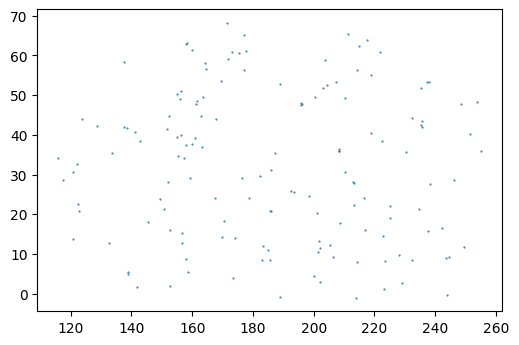

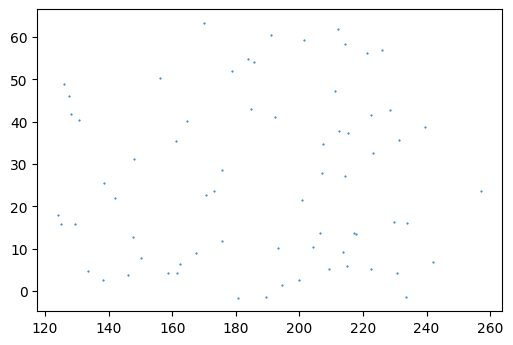

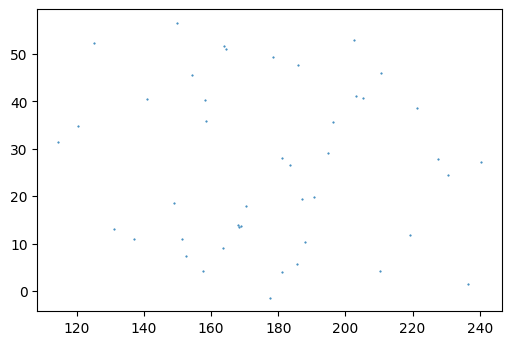

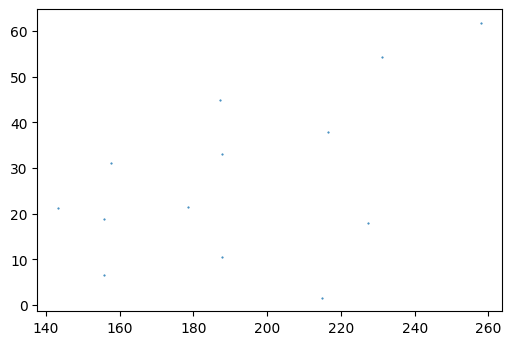

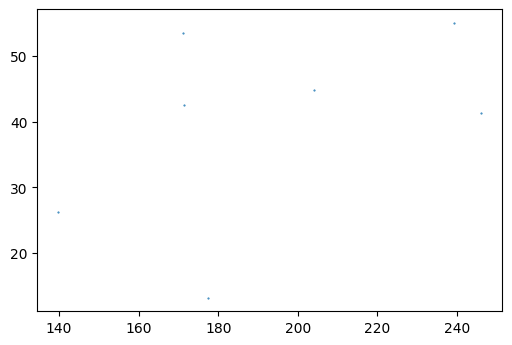

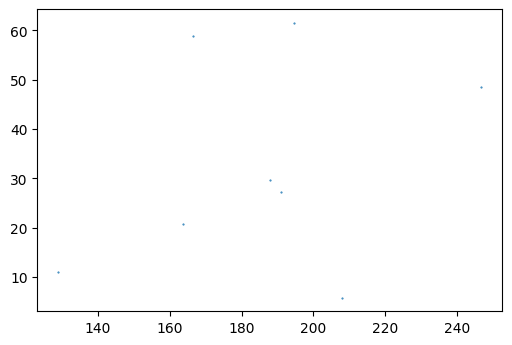

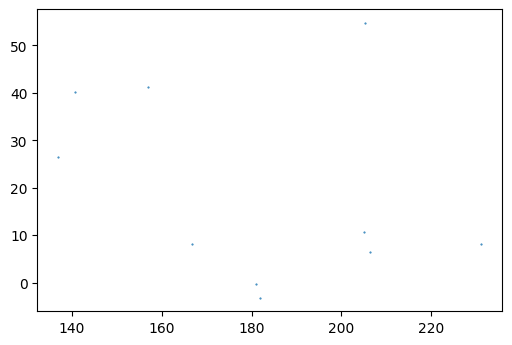

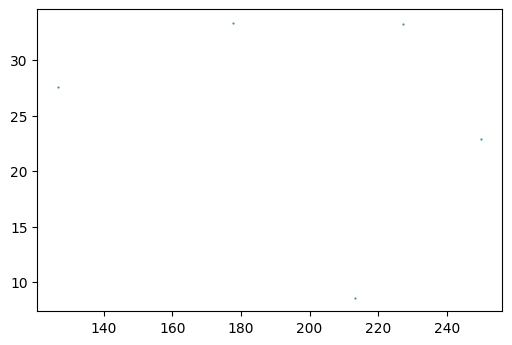

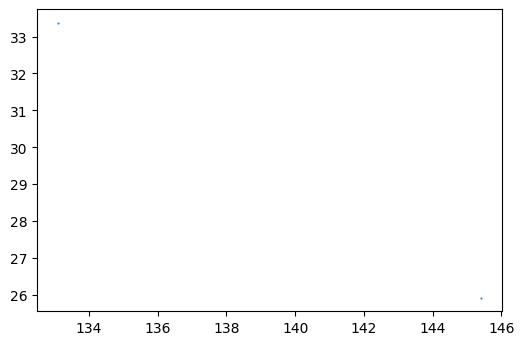

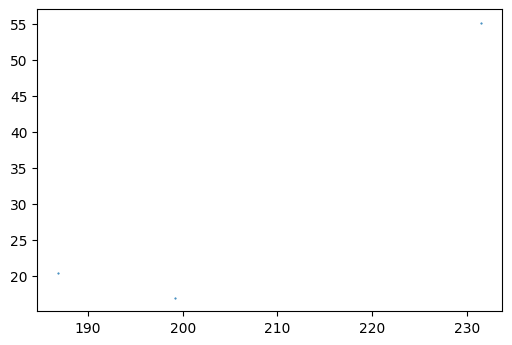

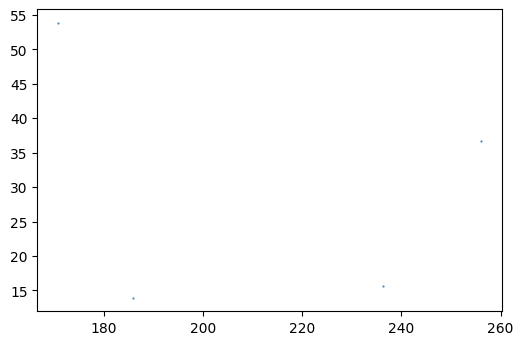

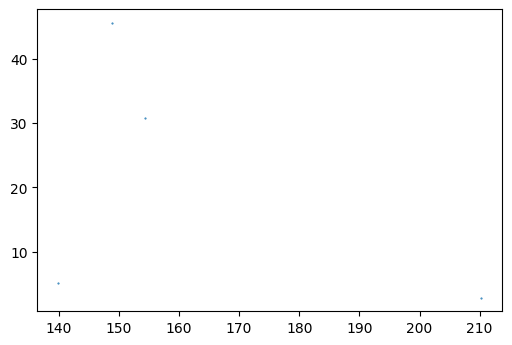

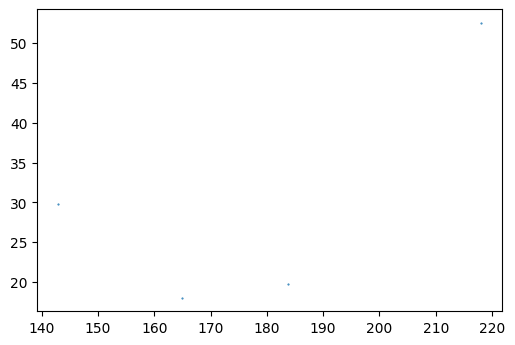

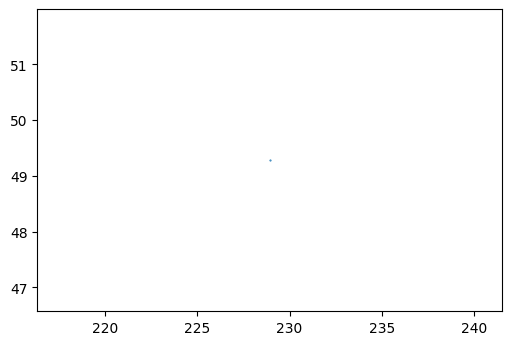

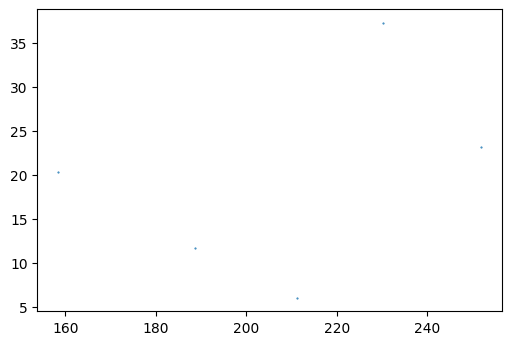

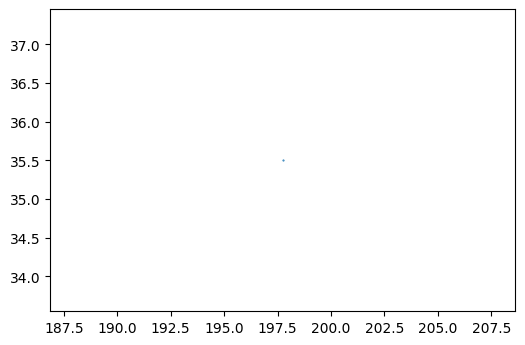

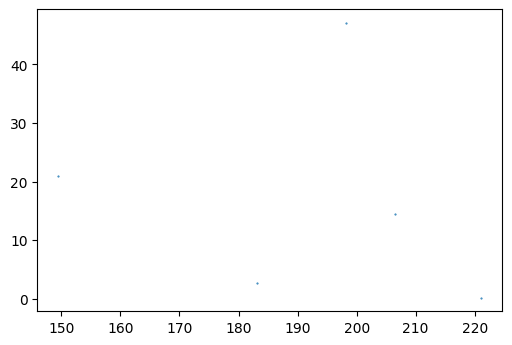

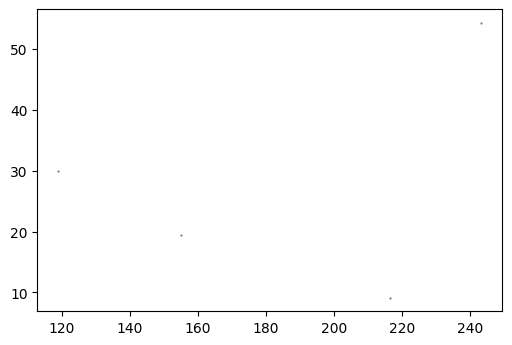

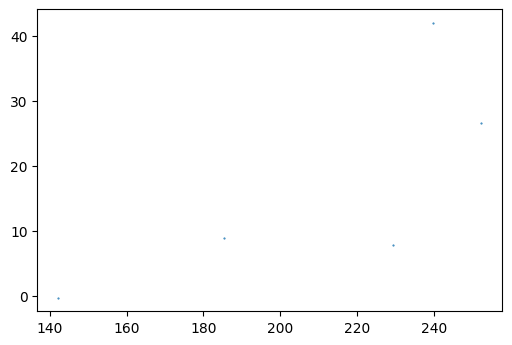

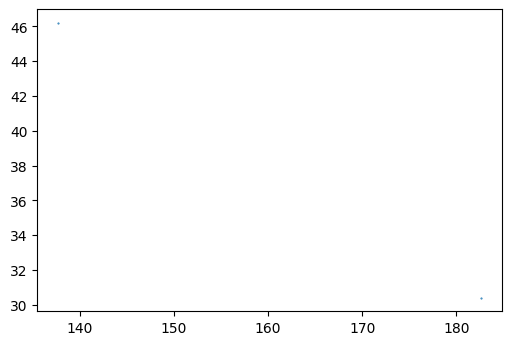

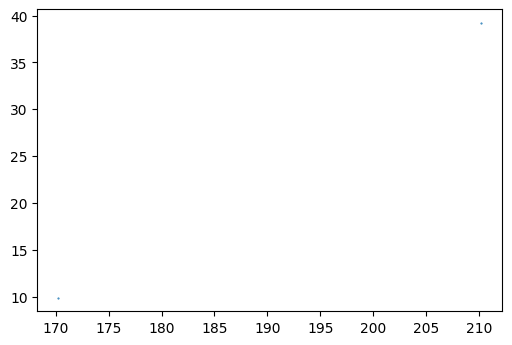

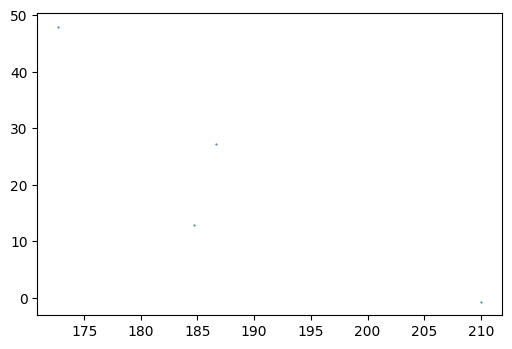

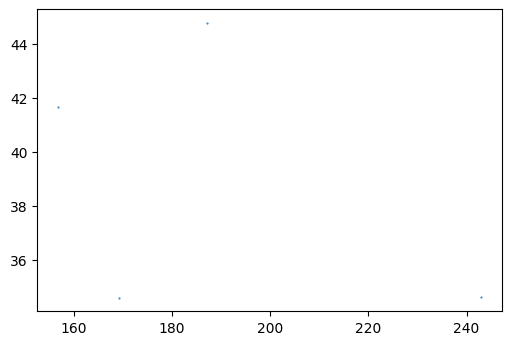

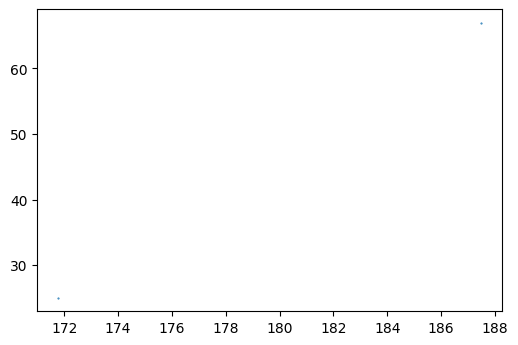

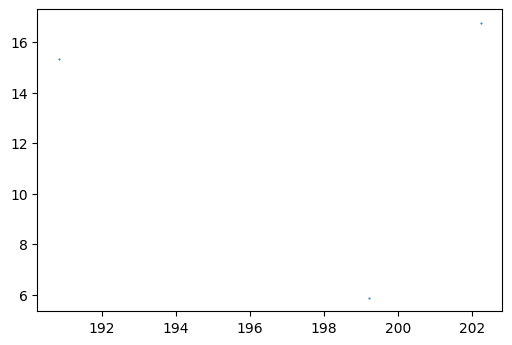

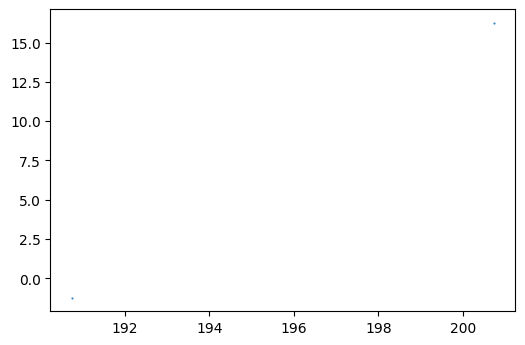

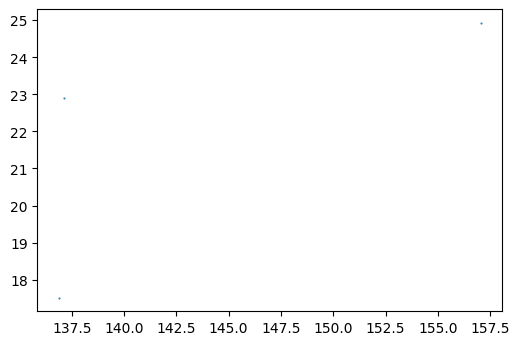

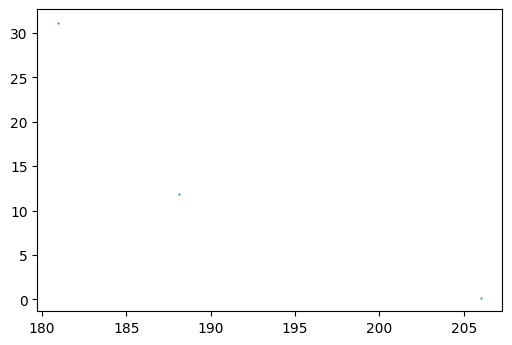

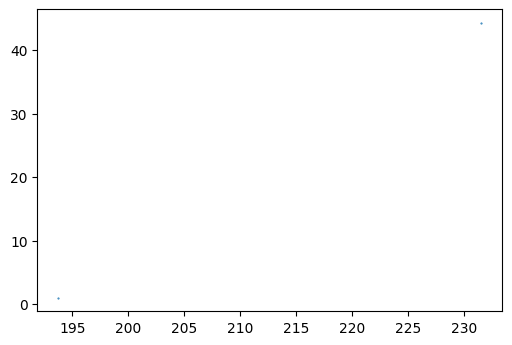

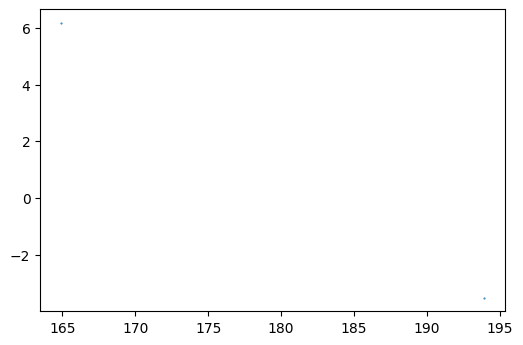

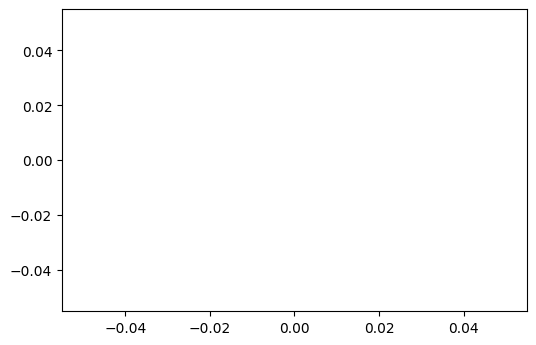

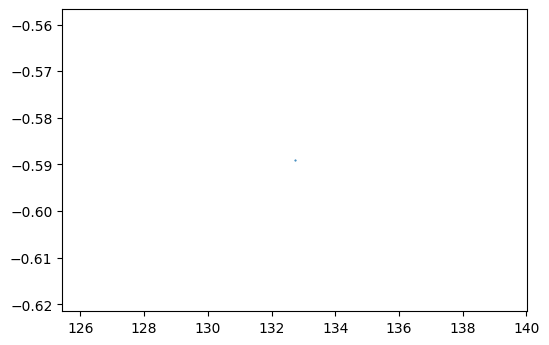

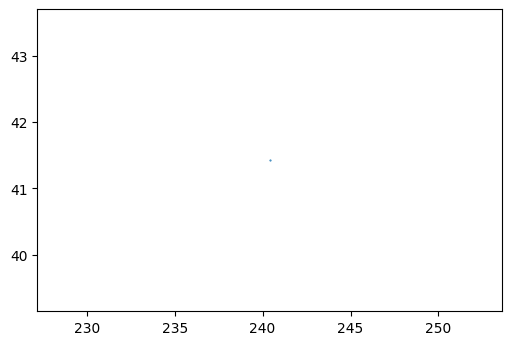

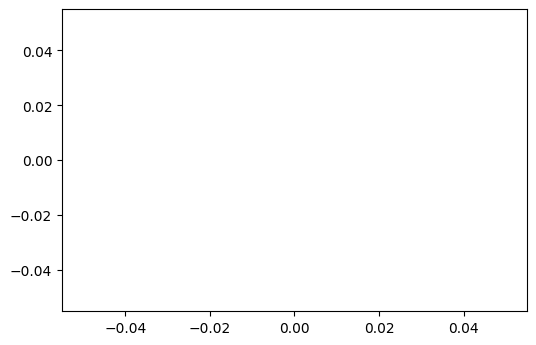

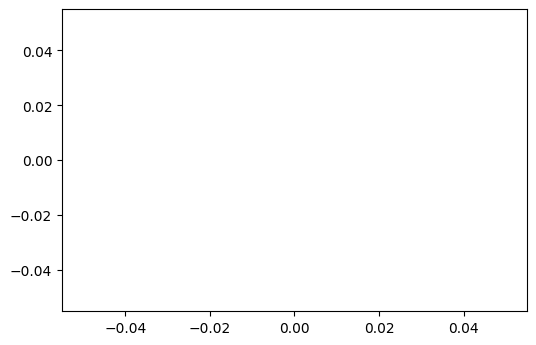

In [36]:
for mask in zMasks:
    plt.figure(dpi= 100)
    plt.scatter(all_gals['ra'][mask], all_gals['dec'][mask], s=1, marker='.')
    plt.show()